In [1]:
import pandas as pd
import numpy as np

In [2]:
df =pd.read_csv("cc_info.csv")
df

,credit_card,city,state,zipcode,credit_card_limit
0,1280981422329509,Dallas,PA,18612,6000
1,9737219864179988,Houston,PA,15342,16000
2,4749889059323202,Auburn,MA,1501,14000
3,9591503562024072,Orlando,WV,26412,18000
4,2095640259001271,New York,NY,10001,20000
...,...,...,...,...,...
979,8938296722055540,Houston,PA,15342,36000
980,2756688131944353,Washington,NH,3280,15000
981,5783648852115715,Washington,NH,3280,20000
982,8259854075192493,Omaha,GA,31821,10000


In [3]:
df.columns

Index(['credit_card', 'city', 'state', 'zipcode', 'credit_card_limit'], dtype='object')

In [4]:
df.shape

(984, 5)

In [5]:
df.describe()

,credit_card,zipcode,credit_card_limit
count,9.840000e+02,984.000000,984.000000
mean,5.410432e+15,17895.316057,12321.138211
std,2.545234e+15,23778.651105,7398.449174
min,1.003715e+15,690.000000,2000.000000
25%,3.316062e+15,3280.000000,7000.000000
50%,5.365218e+15,5820.000000,10000.000000
75%,7.562153e+15,18101.250000,16000.000000
max,9.999757e+15,98401.000000,55000.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   credit_card        984 non-null    int64 
 1   city               984 non-null    object
 2   state              984 non-null    object
 3   zipcode            984 non-null    int64 
 4   credit_card_limit  984 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 38.6+ KB


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [10]:
df['city']=le.fit_transform(df['city'])
df['state']=le.fit_transform(df['state'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   credit_card        984 non-null    int64
 1   city               984 non-null    int64
 2   state              984 non-null    int64
 3   zipcode            984 non-null    int64
 4   credit_card_limit  984 non-null    int64
dtypes: int64(5)
memory usage: 38.6 KB


In [11]:
df

,credit_card,city,state,zipcode,credit_card_limit
0,1280981422329509,29,26,18612,6000
1,9737219864179988,50,26,15342,16000
2,4749889059323202,6,14,1501,14000
3,9591503562024072,84,34,26412,18000
4,2095640259001271,78,23,10001,20000
...,...,...,...,...,...
979,8938296722055540,50,26,15342,36000
980,2756688131944353,119,20,3280,15000
981,5783648852115715,119,20,3280,20000
982,8259854075192493,83,6,31821,10000


In [12]:
from sklearn.cluster import KMeans
x=df[['credit_card','credit_card_limit']]

In [13]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(df)

In [14]:
x=pd.DataFrame(df)
x.head()

,credit_card,city,state,zipcode,credit_card_limit
0,1280981422329509,29,26,18612,6000
1,9737219864179988,50,26,15342,16000
2,4749889059323202,6,14,1501,14000
3,9591503562024072,84,34,26412,18000
4,2095640259001271,78,23,10001,20000


In [16]:
from sklearn.cluster import KMeans
km=KMeans(random_state=1)
km.fit(df)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [17]:
km.cluster_centers_

array([[3.56426150e+15, 7.84285714e+01, 2.02714286e+01, 2.01198857e+04,
        1.20500000e+04],
       [7.15683203e+15, 7.71583333e+01, 2.02500000e+01, 2.19247333e+04,
        1.15583333e+04],
       [8.17220871e+15, 8.16311475e+01, 2.03770492e+01, 1.72045984e+04,
        1.24098361e+04],
       [1.44861962e+15, 7.38725490e+01, 2.08725490e+01, 1.64059804e+04,
        1.29411765e+04],
       [5.95447381e+15, 8.22836879e+01, 1.97446809e+01, 1.77700284e+04,
        1.20567376e+04],
       [4.74082134e+15, 8.23309859e+01, 2.15774648e+01, 1.29888028e+04,
        1.31619718e+04],
       [2.38561774e+15, 8.27904762e+01, 2.08380952e+01, 1.89081810e+04,
        1.12952381e+04],
       [9.44653944e+15, 8.54732143e+01, 2.08214286e+01, 1.83350446e+04,
        1.30446429e+04]])

In [18]:
km.inertia_

1.0280002152642202e+32

In [19]:
labels=km.labels_
labels

array([3, 7, 5, 7, 6, 6, 4, 1, 2, 2, 2, 5, 2, 2, 6, 0, 6, 7, 7, 6, 2, 4,
       4, 6, 2, 5, 1, 1, 5, 7, 3, 3, 3, 5, 7, 6, 4, 2, 2, 7, 0, 4, 1, 7,
       7, 6, 7, 5, 5, 7, 3, 5, 5, 4, 3, 6, 1, 1, 7, 2, 6, 4, 4, 2, 4, 6,
       0, 2, 5, 2, 4, 4, 5, 5, 4, 3, 6, 0, 6, 1, 1, 2, 0, 2, 0, 6, 0, 2,
       2, 1, 0, 3, 7, 2, 4, 7, 0, 1, 2, 5, 7, 0, 5, 0, 0, 4, 0, 2, 2, 2,
       1, 4, 2, 4, 6, 7, 5, 1, 2, 0, 0, 4, 5, 7, 7, 2, 4, 4, 5, 5, 2, 0,
       1, 0, 1, 1, 2, 6, 5, 5, 2, 1, 4, 2, 0, 0, 4, 0, 1, 5, 1, 1, 1, 3,
       1, 5, 2, 0, 0, 7, 6, 5, 7, 7, 7, 6, 3, 3, 7, 4, 6, 4, 3, 3, 5, 2,
       1, 6, 3, 5, 5, 3, 0, 0, 0, 1, 5, 3, 2, 7, 4, 3, 0, 1, 4, 5, 5, 6,
       1, 4, 1, 5, 5, 6, 4, 3, 4, 4, 5, 7, 2, 2, 4, 4, 7, 2, 5, 0, 6, 7,
       0, 4, 0, 6, 5, 5, 4, 4, 6, 7, 0, 6, 0, 5, 6, 7, 5, 7, 2, 3, 0, 1,
       6, 6, 0, 7, 4, 0, 5, 0, 1, 0, 4, 4, 7, 3, 0, 6, 5, 0, 4, 3, 4, 3,
       2, 4, 1, 5, 1, 2, 5, 0, 1, 2, 1, 5, 7, 7, 7, 7, 7, 1, 6, 1, 5, 1,
       6, 4, 5, 3, 6, 1, 0, 0, 1, 7, 6, 2, 5, 2, 3,

In [21]:
from sklearn.metrics import silhouette_score
sc=silhouette_score(df,km.labels_)
print(sc)

0.5469375869849208


In [22]:
import matplotlib.pyplot as plt

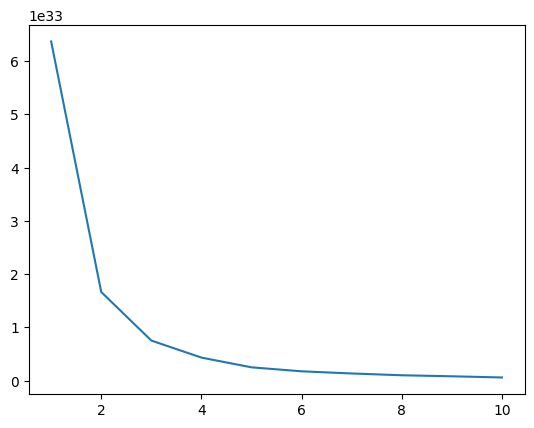

In [23]:
from sklearn.cluster import KMeans
sc=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,init='k-means++',random_state=1)
    km.fit(df)
    sc.append(km.inertia_)
plt.plot(range(1,11),sc)
plt.show()

In [24]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3,random_state=2)
km.fit(df)
labels=km.labels_
labels
from sklearn.metrics import silhouette_score
sc=silhouette_score(df,km.labels_)
print(sc)

0.5796729849233202


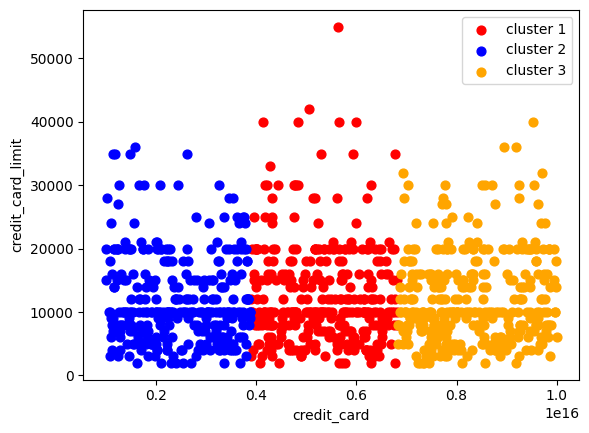

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
x=df[['credit_card','credit_card_limit']]
plt.scatter(x[km.labels_==0]['credit_card'],x[km.labels_==0]['credit_card_limit'],s=40,c='red',label='cluster 1')
plt.scatter(x[km.labels_==1]['credit_card'],x[km.labels_==1]['credit_card_limit'],s=40,c='blue',label='cluster 2')
plt.scatter(x[km.labels_==2]['credit_card'],x[km.labels_==2]['credit_card_limit'],s=40,c='orange',label='cluster 3')
plt.xlabel('credit_card')
plt.ylabel('credit_card_limit')
plt.legend()
plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering
md=AgglomerativeClustering()
md.fit(df)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [27]:
md.linkage

'ward'

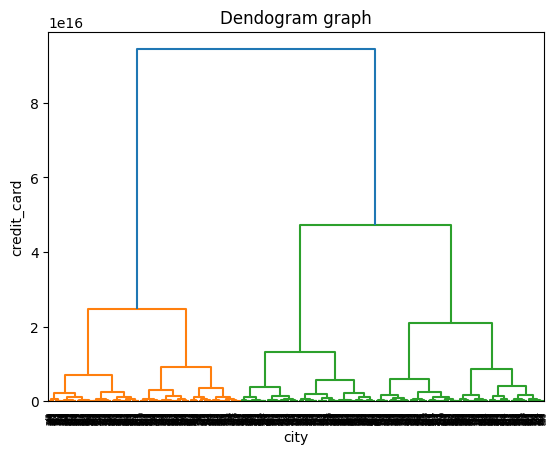

In [28]:
import scipy.cluster.hierarchy as cl 
plt.Figure(figsize=(17,9))
den=cl.dendrogram(cl.linkage(df,method='ward'))
plt.title('Dendogram graph')
plt.xlabel('city')
plt.ylabel('credit_card')
plt.show()

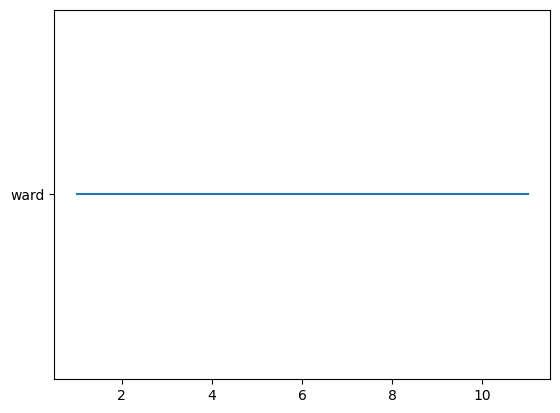

In [29]:
from sklearn.cluster import AgglomerativeClustering
sd=[]
for i in range(1,12):
    md=AgglomerativeClustering(n_clusters=i,linkage='ward')
    md.fit(df)
    sd.append(md.linkage)
plt.plot(range(1,12),sd) 
plt.show()   

In [30]:
from sklearn.cluster import AgglomerativeClustering
md=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_mean=md.fit_predict(df)
y_mean

array([1, 2, 0, 2, 1, 1, 0, 4, 4, 4, 4, 0, 4, 2, 1, 3, 1, 2, 2, 1, 2, 0,
       0, 1, 2, 0, 4, 4, 0, 2, 1, 1, 1, 0, 2, 3, 0, 2, 4, 2, 3, 0, 4, 2,
       2, 1, 2, 0, 0, 2, 1, 0, 0, 0, 1, 1, 4, 4, 2, 2, 1, 0, 0, 4, 0, 1,
       3, 2, 0, 2, 0, 0, 3, 3, 0, 1, 1, 3, 1, 4, 4, 2, 3, 2, 3, 1, 3, 4,
       2, 4, 3, 1, 2, 4, 0, 2, 3, 0, 4, 3, 2, 3, 0, 3, 3, 0, 3, 4, 4, 4,
       4, 0, 2, 0, 1, 2, 0, 4, 2, 3, 3, 0, 3, 2, 2, 4, 0, 0, 0, 0, 2, 3,
       4, 3, 4, 4, 4, 1, 0, 0, 2, 4, 0, 4, 3, 3, 0, 3, 4, 3, 4, 4, 4, 1,
       4, 3, 4, 3, 3, 2, 1, 0, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0, 1, 1, 0, 2,
       4, 1, 1, 0, 0, 1, 3, 3, 3, 4, 3, 1, 2, 2, 0, 1, 3, 4, 0, 0, 0, 1,
       4, 0, 0, 0, 0, 1, 0, 1, 0, 0, 3, 2, 2, 4, 0, 0, 2, 2, 0, 3, 1, 2,
       3, 0, 3, 1, 0, 0, 0, 0, 1, 2, 3, 1, 3, 3, 1, 2, 0, 2, 4, 1, 3, 4,
       1, 1, 3, 2, 0, 3, 3, 3, 4, 3, 0, 0, 2, 1, 3, 1, 0, 3, 0, 1, 0, 1,
       4, 0, 4, 3, 4, 2, 0, 3, 4, 2, 4, 3, 2, 2, 2, 2, 2, 4, 3, 4, 0, 4,
       1, 0, 3, 1, 1, 0, 3, 3, 4, 2, 1, 4, 0, 4, 1,

In [31]:
label=md.labels_
label

array([1, 2, 0, 2, 1, 1, 0, 4, 4, 4, 4, 0, 4, 2, 1, 3, 1, 2, 2, 1, 2, 0,
       0, 1, 2, 0, 4, 4, 0, 2, 1, 1, 1, 0, 2, 3, 0, 2, 4, 2, 3, 0, 4, 2,
       2, 1, 2, 0, 0, 2, 1, 0, 0, 0, 1, 1, 4, 4, 2, 2, 1, 0, 0, 4, 0, 1,
       3, 2, 0, 2, 0, 0, 3, 3, 0, 1, 1, 3, 1, 4, 4, 2, 3, 2, 3, 1, 3, 4,
       2, 4, 3, 1, 2, 4, 0, 2, 3, 0, 4, 3, 2, 3, 0, 3, 3, 0, 3, 4, 4, 4,
       4, 0, 2, 0, 1, 2, 0, 4, 2, 3, 3, 0, 3, 2, 2, 4, 0, 0, 0, 0, 2, 3,
       4, 3, 4, 4, 4, 1, 0, 0, 2, 4, 0, 4, 3, 3, 0, 3, 4, 3, 4, 4, 4, 1,
       4, 3, 4, 3, 3, 2, 1, 0, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0, 1, 1, 0, 2,
       4, 1, 1, 0, 0, 1, 3, 3, 3, 4, 3, 1, 2, 2, 0, 1, 3, 4, 0, 0, 0, 1,
       4, 0, 0, 0, 0, 1, 0, 1, 0, 0, 3, 2, 2, 4, 0, 0, 2, 2, 0, 3, 1, 2,
       3, 0, 3, 1, 0, 0, 0, 0, 1, 2, 3, 1, 3, 3, 1, 2, 0, 2, 4, 1, 3, 4,
       1, 1, 3, 2, 0, 3, 3, 3, 4, 3, 0, 0, 2, 1, 3, 1, 0, 3, 0, 1, 0, 1,
       4, 0, 4, 3, 4, 2, 0, 3, 4, 2, 4, 3, 2, 2, 2, 2, 2, 4, 3, 4, 0, 4,
       1, 0, 3, 1, 1, 0, 3, 3, 4, 2, 1, 4, 0, 4, 1,

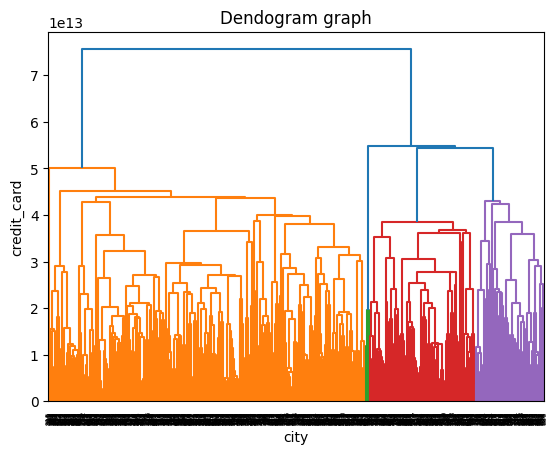

In [32]:
import scipy.cluster.hierarchy as cl 
plt.Figure(figsize=(17,9))
den=cl.dendrogram(cl.linkage(df,method='single'))
plt.title('Dendogram graph')
plt.xlabel('city')
plt.ylabel('credit_card')
plt.show()

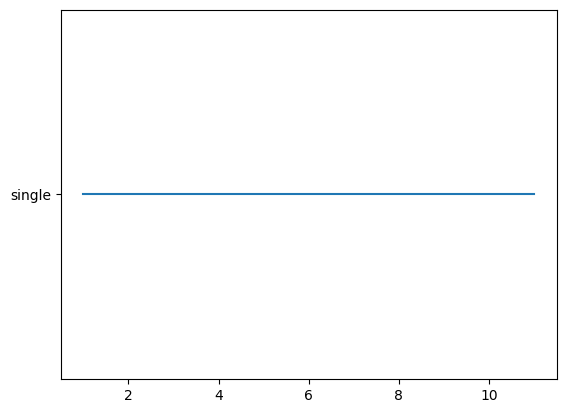

In [33]:
from sklearn.cluster import AgglomerativeClustering
sd=[]
for i in range(1,12):
    md=AgglomerativeClustering(n_clusters=i,linkage='single')
    md.fit(df)
    sd.append(md.linkage)
plt.plot(range(1,12),sd) 
plt.show()  

In [34]:
from sklearn.cluster import AgglomerativeClustering
md=AgglomerativeClustering(n_clusters=5,linkage='single')
y_mean=md.fit_predict(df)
y_mean

array([0, 1, 0, 1, 0, 0, 0, 3, 3, 3, 3, 0, 3, 1, 0, 0, 0, 1, 1, 0, 3, 0,
       0, 0, 1, 0, 3, 3, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 3, 1, 0, 0, 3, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 3, 1, 1, 0, 0, 0, 3, 0, 0,
       0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 0, 3, 0, 0, 0, 3,
       1, 3, 0, 0, 1, 3, 0, 1, 0, 3, 3, 0, 1, 0, 0, 0, 0, 0, 0, 3, 3, 3,
       3, 0, 3, 0, 0, 1, 0, 3, 1, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 3, 0,
       3, 0, 3, 3, 3, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 3, 3, 0,
       3, 0, 3, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 1, 0, 0, 0, 3, 0, 0, 0, 0,
       3, 0, 3, 0, 0, 0, 0, 4, 0, 0, 0, 1, 1, 3, 0, 0, 1, 3, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 3, 0, 0, 3,
       0, 0, 0, 1, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       3, 0, 3, 0, 3, 1, 0, 0, 3, 1, 3, 0, 1, 1, 1, 1, 1, 3, 0, 3, 0, 3,
       0, 0, 0, 0, 0, 3, 0, 0, 3, 1, 0, 3, 0, 3, 0,

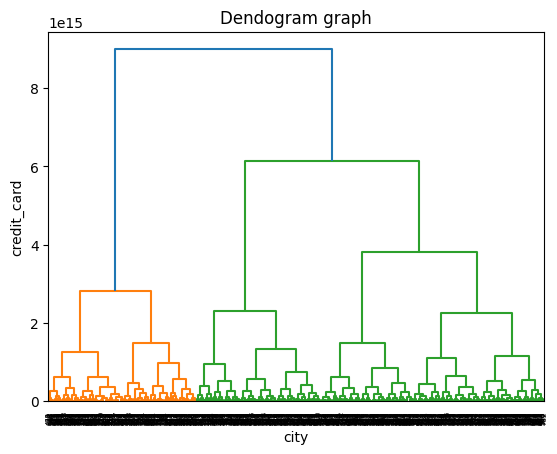

In [36]:
import scipy.cluster.hierarchy as cl 
plt.Figure(figsize=(17,9))
den=cl.dendrogram(cl.linkage(df,method='complete'))
plt.title('Dendogram graph')
plt.xlabel('city')
plt.ylabel('credit_card')
plt.show()

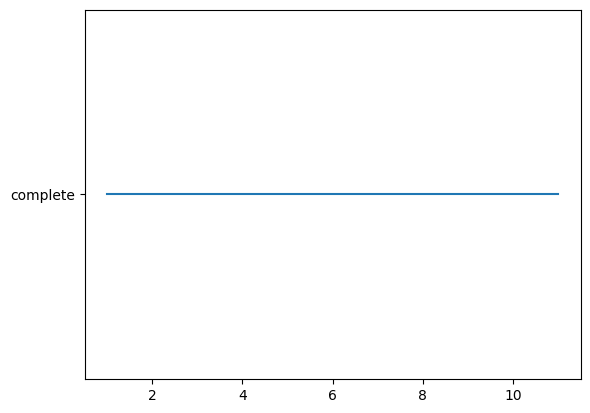

In [37]:
from sklearn.cluster import AgglomerativeClustering
sd=[]
for i in range(1,12):
    md=AgglomerativeClustering(n_clusters=i,linkage='complete')
    md.fit(df)
    sd.append(md.linkage)
plt.plot(range(1,12),sd) 
plt.show()  

In [38]:
from sklearn.cluster import AgglomerativeClustering
md=AgglomerativeClustering(n_clusters=5,linkage='complete')
y_mean=md.fit_predict(df)
y_mean

array([0, 2, 3, 2, 0, 0, 1, 4, 4, 4, 4, 1, 4, 2, 0, 3, 0, 2, 2, 0, 4, 1,
       1, 0, 2, 1, 1, 1, 3, 2, 0, 0, 0, 3, 2, 0, 1, 2, 4, 2, 0, 1, 4, 2,
       2, 0, 2, 1, 3, 2, 0, 3, 3, 1, 0, 0, 1, 1, 2, 2, 0, 1, 1, 4, 1, 0,
       0, 4, 3, 2, 1, 1, 3, 3, 1, 0, 0, 0, 0, 4, 1, 4, 0, 4, 3, 0, 0, 4,
       2, 4, 3, 0, 2, 4, 1, 2, 3, 1, 4, 3, 2, 3, 3, 3, 3, 1, 3, 4, 4, 4,
       1, 1, 4, 1, 0, 2, 1, 1, 2, 0, 3, 1, 3, 2, 2, 4, 1, 1, 1, 1, 4, 3,
       4, 0, 4, 4, 4, 0, 3, 1, 4, 4, 1, 4, 3, 3, 1, 3, 1, 3, 4, 1, 4, 0,
       1, 3, 4, 3, 0, 2, 0, 1, 2, 2, 2, 0, 0, 0, 2, 1, 0, 1, 0, 0, 1, 2,
       4, 0, 0, 3, 1, 0, 3, 3, 3, 4, 3, 0, 4, 2, 1, 0, 3, 1, 1, 3, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 3, 2, 2, 4, 1, 1, 2, 4, 1, 3, 0, 2,
       3, 1, 0, 0, 1, 3, 1, 1, 0, 2, 3, 0, 3, 3, 0, 2, 1, 2, 4, 0, 3, 4,
       0, 0, 3, 2, 1, 3, 3, 3, 4, 3, 1, 1, 2, 0, 3, 0, 1, 3, 1, 0, 1, 0,
       4, 1, 1, 3, 4, 2, 1, 3, 4, 2, 4, 3, 2, 2, 2, 2, 2, 1, 0, 4, 3, 4,
       0, 1, 3, 0, 0, 1, 3, 3, 4, 2, 0, 4, 3, 4, 0,

In [39]:
from sklearn.metrics import silhouette_score
sc=silhouette_score(df,md.labels_)
print(sc)

0.5280605842523538


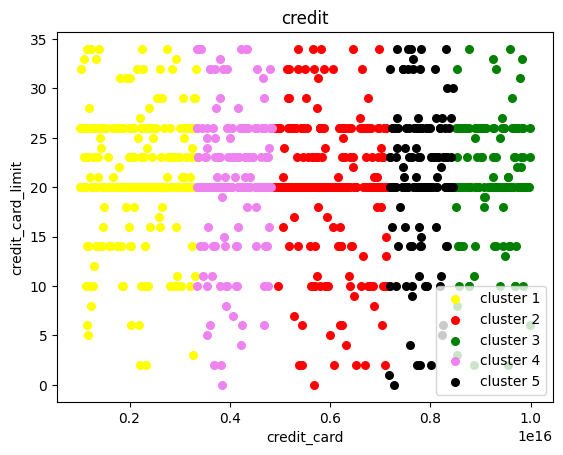

In [40]:
x=df.iloc[:,[0,2]].values
plt.scatter(x[y_mean==0,0], x[y_mean==0,1],s=30,c='yellow',label='cluster 1')
plt.scatter(x[y_mean==1,0], x[y_mean==1,1],s=30,c='red',label='cluster 2')
plt.scatter(x[y_mean==2,0], x[y_mean==2,1],s=30,c='green',label='cluster 3')
plt.scatter(x[y_mean==3,0], x[y_mean==3,1],s=30,c='violet',label='cluster 4')
plt.scatter(x[y_mean==4,0], x[y_mean==4,1],s=30,c='black',label='cluster 5')
plt.legend()
plt.title('credit')
plt.xlabel('credit_card')
plt.ylabel('credit_card_limit')
plt.show()

In [41]:
from sklearn.cluster import DBSCAN
mo=DBSCAN(eps=0.5,min_samples=3)
mo.fit(df)

,eps,0.5
,min_samples,3
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [42]:
from sklearn.metrics import silhouette_score
s=silhouette_score(df,md.labels_,sample_size=23)
print(s)

0.3588970510725056


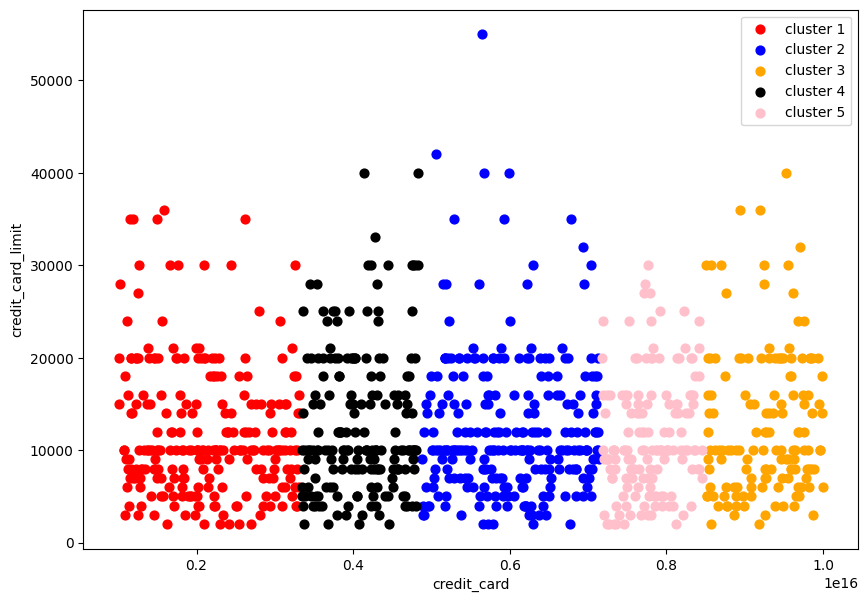

In [43]:
plt.figure(figsize=(10,7))
x=df[['credit_card','credit_card_limit']]
plt.scatter(x[md.labels_==0]['credit_card'],x[md.labels_==0]['credit_card_limit'],s=40,c='red',label='cluster 1')
plt.scatter(x[md.labels_==1]['credit_card'],x[md.labels_==1]['credit_card_limit'],s=40,c='blue',label='cluster 2')
plt.scatter(x[md.labels_==2]['credit_card'],x[md.labels_==2]['credit_card_limit'],s=40,c='orange',label='cluster 3')
plt.scatter(x[md.labels_==3]['credit_card'],x[md.labels_==3]['credit_card_limit'],s=40,c='black',label='cluster 4')
plt.scatter(x[md.labels_==4]['credit_card'],x[md.labels_==4]['credit_card_limit'],s=40,c='pink',label='cluster 5')
plt.xlabel('credit_card')
plt.ylabel('credit_card_limit')
plt.legend()
plt.show()